<a href="https://colab.research.google.com/github/deepakawl/supplychain-analytics-teaching/blob/main/Network_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Network Analysis

In [25]:
!pip install networkx matplotlib
import pandas as pd, networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [6]:
#Nodes file: https://raw.githubusercontent.com/deepakawl/supplychain-analytics-teaching/refs/heads/main/SunOilNodes.csv
#Edges file: https://raw.githubusercontent.com/deepakawl/supplychain-analytics-teaching/refs/heads/main/SunOilEdges.csv
nodes = pd.read_csv('https://raw.githubusercontent.com/deepakawl/supplychain-analytics-teaching/refs/heads/main/SunOilNodes.csv')
edges = pd.read_csv('https://raw.githubusercontent.com/deepakawl/supplychain-analytics-teaching/refs/heads/main/SunOilEdges.csv')

In [11]:
print(G.nodes['Asia'])

{'Demand': 16, 'F.Cost LowCap': 4100, 'LowCap': 10, 'F.Cost HighCap': 6150, 'HighCap': 20}


In [13]:
print(G.edges)

[('N. America', 'N. America'), ('N. America', 'S. America'), ('N. America', 'Europe'), ('N. America', 'Asia'), ('N. America', 'Africa'), ('S. America', 'N. America'), ('S. America', 'S. America'), ('S. America', 'Europe'), ('S. America', 'Asia'), ('S. America', 'Africa'), ('Europe', 'N. America'), ('Europe', 'S. America'), ('Europe', 'Europe'), ('Europe', 'Asia'), ('Europe', 'Africa'), ('Asia', 'N. America'), ('Asia', 'S. America'), ('Asia', 'Europe'), ('Asia', 'Asia'), ('Asia', 'Africa'), ('Africa', 'N. America'), ('Africa', 'S. America'), ('Africa', 'Europe'), ('Africa', 'Asia'), ('Africa', 'Africa')]


In [21]:
# ── Add Flow column with default 0 ───────────────────────────────────────────
edges['Flow'] = 0

# ── Assign flow values (directed: Source → Target matters) ───────────────────
flow_assignments = {
    ('S. America','N. America'): 12,
    ('S. America','S. America'): 8,
    ('Asia', 'Europe'): 4,
    ('Asia', 'Asia'): 16,
    ('Africa', 'Europe'): 10,
    ('Africa', 'Africa'): 7
}

for (src, tgt), flow in flow_assignments.items():
    mask = (edges['Source'] == src) & (edges['Target'] == tgt)
    edges.loc[mask, 'Flow'] = flow

In [23]:
G = nx.from_pandas_edgelist(
    edges, source='Source', target='Target',
    edge_attr=['Cost','Flow'], create_using=nx.DiGraph()
)

attrs = nodes.set_index('ID').to_dict('index')
nx.set_node_attributes(G, attrs)

print(f'Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}')

Nodes: 5 | Edges: 25


In [24]:
# Active graph (Flow > 0 only)
G_active = nx.from_pandas_edgelist(
    edges[edges['Flow'] > 0],
    source='Source', target='Target',
    edge_attr=['Cost', 'Flow'],
    create_using=nx.DiGraph()
)
nx.set_node_attributes(G_active, nodes.set_index('ID').to_dict('index'))

print(f"Full graph:   {G.number_of_edges()} edges")
print(f"Active graph: {G_active.number_of_edges()} edges")


Full graph:   25 edges
Active graph: 6 edges


## Visualize SC Network

In [44]:
pos = {'N. America': (-2, 1), 'S. America': (-1, -1),
       'Europe': (0, 2), 'Asia': (2, 1), 'Africa': (1, -1)}

def draw_network(g, pos, title):
    inactive = [(u, v) for u, v, d in g.edges(data=True) if d['Flow'] == 0]
    active   = [(u, v) for u, v, d in g.edges(data=True) if d['Flow'] > 0]

    fig, ax = plt.subplots(figsize=(7, 6))
    nx.draw_networkx_edges(g, pos, ax=ax, edgelist=inactive,
                           edge_color='lightgray', style='dashed', arrows=True, width=4)
    nx.draw_networkx_edges(g, pos, ax=ax, edgelist=active,
                           edge_color='teal', arrows=True, width=4)
    nx.draw_networkx_nodes(g, pos, ax=ax, node_color='steelblue', node_size=800)
    nx.draw_networkx_labels(g, pos, ax=ax, font_color='black', font_size=11)
    nx.draw_networkx_edge_labels(g, pos, ax=ax, font_size=9,
                                  edge_labels={(u, v): f"F={d['Flow']}"
                                               for u, v, d in g.edges(data=True) if d['Flow'] > 0})
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

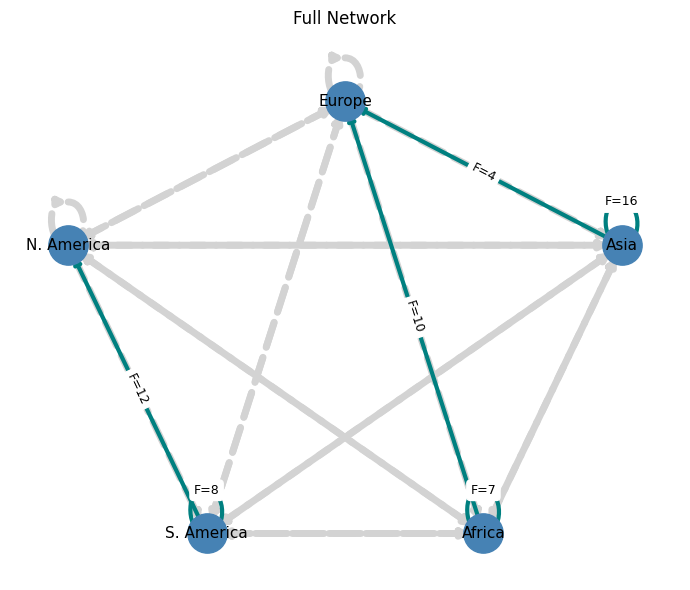

In [43]:
# ── Figure 1: Full network ────────────────────────────────────────────────────
draw_network(G, pos, 'Full Network')

In [45]:
pos = {'N. America': (-2, 1), 'S. America': (-1, -1),
       'Europe': (0, 2), 'Asia': (2, 1), 'Africa': (1, -1)}

def draw_network2(g, pos, title):
    inactive = [(u, v) for u, v, d in g.edges(data=True) if d['Flow'] == 0]
    active   = [(u, v) for u, v, d in g.edges(data=True) if d['Flow'] > 0]

    node_sizes  = [g.nodes[n]['Demand'] * 150 for n in g.nodes()]
    edge_widths = [g[u][v]['Cost'] / 20 for u, v in g.edges()]

    fig, ax = plt.subplots(figsize=(7, 6))
    nx.draw_networkx_edges(g, pos, ax=ax, edgelist=inactive,
                           edge_color='lightgray', style='dashed', arrows=True,
                           width=[g[u][v]['Cost'] / 20 for u, v in active])
    nx.draw_networkx_edges(g, pos, ax=ax, edgelist=active,
                           edge_color='teal', arrows=True,
                          #  width=3
                           width=[g[u][v]['Cost'] / 20 for u, v in active]
                           )
    nx.draw_networkx_nodes(g, pos, ax=ax, node_color='steelblue',
                          #  node_size=800
                           node_size=node_sizes
                           )
    nx.draw_networkx_labels(g, pos, ax=ax, font_color='black', font_size=11)
    nx.draw_networkx_edge_labels(g, pos, ax=ax, font_size=9,
                                  edge_labels={(u, v): f"F={d['Flow']}"
                                               for u, v, d in g.edges(data=True) if d['Flow'] > 0})
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

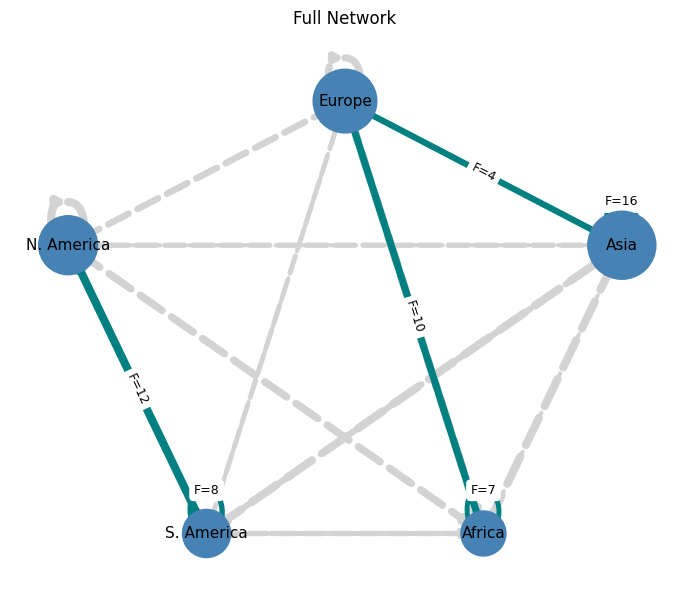

In [46]:
# ── Figure 1: Full network ────────────────────────────────────────────────────
draw_network2(G, pos, 'Full Network')

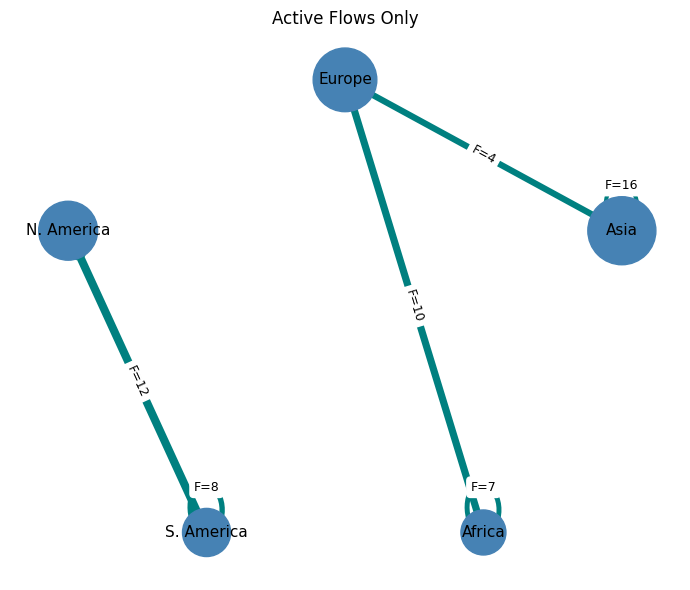

In [48]:
# ── Figure 2: Active flows only ───────────────────────────────────────────────
G_active = G.copy()
G_active.remove_edges_from([(u, v) for u, v, d in G.edges(data=True) if d['Flow'] == 0])

draw_network2(G_active, pos, 'Active Flows Only')

## Data Analysis

In [75]:
# ── Descendants (downstream) ─────────────────────────────────────────────────
# All nodes reachable FROM a given node (following edge direction)
node = 'Asia'

descendants = nx.descendants(G, node)
print(f"Descendants of {node} (downstream): {descendants}")

# ── Ancestors (upstream) ──────────────────────────────────────────────────────
# All nodes that can REACH a given node (following edge direction)
ancestors = nx.ancestors(G, node)
print(f"Ancestors of {node} (upstream): {ancestors}")

# ── All connected neighbors ───────────────────────────────────────────────────
# Direct neighbors only (one hop), regardless of direction
successors   = list(G.successors(node))    # nodes Asia points TO
predecessors = list(G.predecessors(node))  # nodes that point TO Asia
all_neighbors = set(successors + predecessors)
print(f"Direct successors   (out-edges): {successors}")
print(f"Direct predecessors (in-edges):  {predecessors}")
print(f"All direct neighbors (1 hop):    {all_neighbors}")

Descendants of Asia (downstream): {'Europe', 'S. America', 'N. America', 'Africa'}
Ancestors of Asia (upstream): {'Europe', 'S. America', 'N. America', 'Africa'}
Direct successors   (out-edges): ['N. America', 'S. America', 'Europe', 'Asia', 'Africa']
Direct predecessors (in-edges):  ['N. America', 'S. America', 'Europe', 'Asia', 'Africa']
All direct neighbors (1 hop):    {'S. America', 'Europe', 'N. America', 'Africa', 'Asia'}


In [50]:
# ── Descendants (downstream) ─────────────────────────────────────────────────
# All nodes reachable FROM a given node (following edge direction)
node = 'Asia'

descendants   = nx.descendants(G_active, node)
ancestors     = nx.ancestors(G_active, node)
successors    = list(G_active.successors(node))
predecessors  = list(G_active.predecessors(node))

print(f"Descendants  (downstream): {descendants}")
print(f"Ancestors    (upstream):   {ancestors}")
print(f"Successors   (out-edges):  {successors}")
print(f"Predecessors (in-edges):   {predecessors}")

Descendants  (downstream): {'Europe'}
Ancestors    (upstream):   set()
Successors   (out-edges):  ['Europe', 'Asia']
Predecessors (in-edges):   ['Asia']


## Shortest Path

In [52]:
path = nx.dijkstra_path(G, 'Asia', 'N. America', weight='Cost')
cost = nx.dijkstra_path_length(G, 'Asia', 'N. America', weight='Cost')

print(f'Route: {path}  |  Cost: {cost}')  # → ['Asia', 'Asia'] cost=115 (direct)
# All-pairs shortest path costs

apsp = dict(nx.all_pairs_dijkstra_path_length(G, weight='Cost'))

Route: ['Asia', 'N. America']  |  Cost: 115


## Centrality Measures

In [61]:
deg  = nx.degree_centrality(G)                         # degree
indeg= nx.in_degree_centrality(G)                      # indegree
outdeg=nx.out_degree_centrality(G)                     # outdegree
btw  = nx.betweenness_centrality(G, weight='Cost')     # betweenness
cls  = nx.closeness_centrality(G, distance='Cost')     # closeness
pagerank = nx.pagerank(G, weight='Cost')

# Print as sorted DataFrame
pd.DataFrame({
    'Degree':      deg,
    'In-Degree':   indeg,
    'Out-Degree':  outdeg,
    'Betweenness': btw,
    'Closeness':   cls,
    'PageRank':    pagerank,
}).round(3).sort_values('Betweenness', ascending=False)

,Degree,In-Degree,Out-Degree,Betweenness,Closeness,PageRank
N. America,2.5,1.25,1.25,0.0,0.008,0.216
S. America,2.5,1.25,1.25,0.0,0.009,0.198
Europe,2.5,1.25,1.25,0.0,0.010,0.197
Asia,2.5,1.25,1.25,0.0,0.009,0.200
Africa,2.5,1.25,1.25,0.0,0.010,0.188


In [62]:
deg  = nx.degree_centrality(G_active)                         # degree
indeg= nx.in_degree_centrality(G_active)                      # indegree
outdeg=nx.out_degree_centrality(G_active)                     # outdegree
btw  = nx.betweenness_centrality(G_active, weight='Cost')     # betweenness
cls  = nx.closeness_centrality(G_active, distance='Cost')     # closeness
pagerank = nx.pagerank(G_active, weight='Cost')

# Print as sorted DataFrame
pd.DataFrame({
    'Degree':      deg,
    'In-Degree':   indeg,
    'Out-Degree':  outdeg,
    'Betweenness': btw,
    'Closeness':   cls,
    'PageRank':    pagerank,
}).round(3).sort_values('Betweenness', ascending=False)

,Degree,In-Degree,Out-Degree,Betweenness,Closeness,PageRank
N. America,0.25,0.25,0.0,0.0,0.002,0.200
S. America,0.75,0.25,0.5,0.0,0.000,0.170
Europe,0.50,0.50,0.0,0.0,0.005,0.287
Asia,0.75,0.25,0.5,0.0,0.000,0.170
Africa,0.75,0.25,0.5,0.0,0.000,0.173


## Maxflow

In [77]:
# Capacity-weighted graph (use LowCap as capacity attribute)

# ── Add capacity to edges from source node's LowCap ──────────────────────────
cap_map = nodes.set_index('ID')['LowCap'].to_dict()
edges['LowCap'] = edges['Source'].map(cap_map)

# ── Rebuild graph with capacity attribute ─────────────────────────────────────
G = nx.from_pandas_edgelist(edges, 'Source', 'Target',
                             edge_attr=['Cost', 'Flow', 'LowCap'],
                             create_using=nx.DiGraph())
nx.set_node_attributes(G, nodes.set_index('ID').to_dict('index'))

# ── Max flow ──────────────────────────────────────────────────────────────────
flow_val, flow_dict = nx.maximum_flow(G, 'Asia', 'N. America', capacity='LowCap')
# nx.min_cost_flow(G)  ← requires 'demand','capacity','weight' on all nodes/edges

print(f'Max Flow Asia → N. America: {flow_val}')
print(f'Flow breakdown: {flow_dict["Asia"]}')

Max Flow Asia → N. America: 40
Flow breakdown: {'N. America': 10, 'S. America': 10, 'Europe': 10, 'Asia': 0, 'Africa': 10}
